### Setup

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

#### Parameters

In [2]:
# Common variance parameter for all three lognormal distributions
sigma2 = np.log(2)

# Ward A: mean and standard deviation are both 8 days
mu_A = np.log(4 * np.sqrt(2))

# Ward B: mean and standard deviation are both 12 days
mu_B = np.log(6 * np.sqrt(2))

# Ward C: mean and standard deviation are both 10 days
mu_C = np.log(5 * np.sqrt(2))


def lambda_A(t):
    return max(0, -(1 / 3650) * t**2 + (1 / 10) * t)


def lambda_B(t):
    return (1 / 5) * lambda_A(t)


def lambda_C(t):
    return 6

DAYS = 365


### Ward Class

In [3]:
class Ward:
    def __init__(self, name, beds, arrival_rate_function, mu, sigma2, LOS_exp=False):
        self.name = name
        self.beds = beds
        self.arrival_rate_function = arrival_rate_function
        self.mu = mu
        self.sigma2 = sigma2
        self.sigma = np.sqrt(sigma2)
        self.LOS_exp = LOS_exp
        # Current state
        self.occupied = 0

        # Statistics
        self.total_arrivals = 0
        self.full_on_arrival = 0
        self.relocated = 0
        self.overflow_to_A = 0

        # For continuous-time utilization
        self.occupied_bed_time = 0

        # for plotting
        self.time_points = []
        self.occupancy_points = []

    def record_occupancy(self, t):
        self.time_points.append(t)
        self.occupancy_points.append(self.occupied)

    def arrival_rate(self, t):
        return self.arrival_rate_function(t)
    
    def mean_los(self):
        return np.exp(self.mu + self.sigma2 / 2)

    def sample_los(self):
        if self.LOS_exp:
            return np.random.exponential(scale=self.mean_los())
        else:
            return np.random.lognormal(mean=self.mu, sigma=self.sigma)

    def has_available_bed(self):
        return self.occupied < self.beds

    def admit_patient(self, t):
        self.occupied += 1
        los = self.sample_los()
        discharge_time = t + los
        return discharge_time

    def discharge_patient(self):
        self.occupied -= 1

        if self.occupied < 0:
            raise ValueError(f"Ward {self.name} has negative occupancy.")

    def utilization(self, days=DAYS):
        if self.beds == 0:
            return 0
        return self.occupied_bed_time / (self.beds * days)

    def full_probability(self):
        if self.total_arrivals == 0:
            return 0
        return self.full_on_arrival / self.total_arrivals

    def relocation_probability(self):
        if self.total_arrivals == 0:
            return 0
        return self.relocated / self.total_arrivals

### Hospital class

In [4]:
class Hospital:
    def __init__(self, beds_A, beds_B, beds_C, total_beds=75, LOS_exp=False):
        if beds_A + beds_B + beds_C != total_beds:
            raise ValueError("Beds in A, B, and C must add up to total_beds.")

        self.total_beds = total_beds
        self.current_time = 0

        self.wards = {
            "A": Ward("A", beds_A, lambda_A, mu_A, sigma2, LOS_exp=LOS_exp),
            "B": Ward("B", beds_B, lambda_B, mu_B, sigma2, LOS_exp=LOS_exp),
            "C": Ward("C", beds_C, lambda_C, mu_C, sigma2, LOS_exp=LOS_exp),
        }

    def update_utilization_time(self, new_time):
        dt = new_time - self.current_time

        if dt < 0:
            raise ValueError("Time moved backwards.")

        for ward in self.wards.values():
            ward.occupied_bed_time += ward.occupied * dt

        self.current_time = new_time

    def handle_arrival_A(self, t, event_queue, event_counter):
        ward_A = self.wards["A"]
        ward_A.total_arrivals += 1

        if ward_A.has_available_bed():
            discharge_time = ward_A.admit_patient(t)
            heapq.heappush(event_queue, (discharge_time, event_counter, "discharge_A"))
        else:
            ward_A.full_on_arrival += 1
            ward_A.relocated += 1

    def handle_arrival_B(self, t, event_queue, event_counter):
        ward_A = self.wards["A"]
        ward_B = self.wards["B"]

        ward_B.total_arrivals += 1

        if ward_B.has_available_bed():
            discharge_time = ward_B.admit_patient(t)
            heapq.heappush(event_queue, (discharge_time, event_counter, "discharge_B"))

        else:
            # Ward B is full on arrival
            ward_B.full_on_arrival += 1

            # Intensive patient can overflow into Ward A
            if ward_A.has_available_bed():
                ward_B.overflow_to_A += 1
                discharge_time = ward_A.admit_patient(t)
                heapq.heappush(event_queue, (discharge_time, event_counter, "discharge_A"))
            else:
                ward_B.relocated += 1

    def handle_arrival_C(self, t, event_queue, event_counter):
        ward_C = self.wards["C"]
        ward_C.total_arrivals += 1

        if ward_C.has_available_bed():
            discharge_time = ward_C.admit_patient(t)
            heapq.heappush(event_queue, (discharge_time, event_counter, "discharge_C"))
        else:
            ward_C.full_on_arrival += 1
            ward_C.relocated += 1

    def record_occupancy(self, t):
        for ward in self.wards.values():
            ward.record_occupancy(t)

    def handle_discharge(self, event_type):
        if event_type == "discharge_A":
            self.wards["A"].discharge_patient()
        elif event_type == "discharge_B":
            self.wards["B"].discharge_patient()
        elif event_type == "discharge_C":
            self.wards["C"].discharge_patient()

    def simulate(self, days=DAYS):
        event_queue = []
        event_counter = 0
        self.record_occupancy(0)

        # Generate all arrival events first
        arrivals_A = generate_arrivals_thinning(lambda_A, max_rate=9.125, days=days)
        arrivals_B = generate_arrivals_thinning(lambda_B, max_rate=1.825, days=days)
        arrivals_C = generate_arrivals_constant(rate=6, days=days)

        for t in arrivals_A:
            heapq.heappush(event_queue, (t, event_counter, "arrival_A"))
            event_counter += 1

        for t in arrivals_B:
            heapq.heappush(event_queue, (t, event_counter, "arrival_B"))
            event_counter += 1

        for t in arrivals_C:
            heapq.heappush(event_queue, (t, event_counter, "arrival_C"))
            event_counter += 1

        # Process events in chronological order
        while event_queue:
            t, _, event_type = heapq.heappop(event_queue)

            if t > days:
                break

            self.update_utilization_time(t)

            if event_type == "arrival_A":
                self.handle_arrival_A(t, event_queue, event_counter)
                event_counter += 1

            elif event_type == "arrival_B":
                self.handle_arrival_B(t, event_queue, event_counter)
                event_counter += 1

            elif event_type == "arrival_C":
                self.handle_arrival_C(t, event_queue, event_counter)
                event_counter += 1

            elif event_type.startswith("discharge"):
                self.handle_discharge(event_type)
            
            self.record_occupancy(t)

        # Add occupied-bed time from last event until day 365
        self.update_utilization_time(days)
        self.record_occupancy(days)

    def print_results(self, days=DAYS):
        total_relocated = 0

        for ward_name in ["A", "B", "C"]:
            ward = self.wards[ward_name]
            total_relocated += ward.relocated

            print(f"Ward {ward.name}")
            print(f"Beds: {ward.beds}")
            print(f"Total arrivals: {ward.total_arrivals}")
            print(f"Full on arrival: {ward.full_on_arrival}")
            print(f"Relocated patients: {ward.relocated}")
            print(f"Probability full on arrival: {ward.full_probability():.4f}")
            print(f"Relocation probability: {ward.relocation_probability():.4f}")
            print(f"Mean bed utilization: {ward.utilization(days):.4f}")

            if ward.name == "B":
                print(f"Overflow patients sent to Ward A: {ward.overflow_to_A}")

            print()

        print(f"Total relocated patients: {total_relocated}")

#### Continuous arrival generators

In [5]:
def generate_arrivals_constant(rate, days=DAYS):
    arrivals = []
    t = 0

    while t < days:
        t += np.random.exponential(scale=1 / rate)

        if t < days:
            arrivals.append(t)

    return arrivals


def generate_arrivals_thinning(rate_function, max_rate, days=DAYS):
    arrivals = []
    t = 0

    while t < days:
        # Candidate arrivals from a Poisson process
        t += np.random.exponential(scale=1 / max_rate)

        if t >= days:
            break

        # Accept with probability lambda(t) / max_rate
        accept_prob = rate_function(t) / max_rate

        if np.random.uniform() <= accept_prob:
            arrivals.append(t)

    return arrivals

### Helper Functions

#### Running simulations

In [6]:
def simulate_once(beds_A, beds_B, beds_C, total_beds=75, LOS_exp=False, days=DAYS):
    hospital = Hospital(
        beds_A=beds_A,
        beds_B=beds_B,
        beds_C=beds_C,
        total_beds=total_beds,
        LOS_exp=LOS_exp
    )

    hospital.simulate(days=days)

    ward_A = hospital.wards["A"]
    ward_B = hospital.wards["B"]
    ward_C = hospital.wards["C"]

    result = {
        "total_beds": total_beds,
        "beds_A": beds_A,
        "beds_B": beds_B,
        "beds_C": beds_C,
        "LOS": "Exponential" if LOS_exp else "Lognormal",

        "arrivals_A": ward_A.total_arrivals,
        "arrivals_B": ward_B.total_arrivals,
        "arrivals_C": ward_C.total_arrivals,

        "relocated_A": ward_A.relocated,
        "relocated_B": ward_B.relocated,
        "relocated_C": ward_C.relocated,
        "total_relocated": ward_A.relocated + ward_B.relocated + ward_C.relocated,

        "full_prob_A": ward_A.full_probability(),
        "full_prob_B": ward_B.full_probability(),
        "full_prob_C": ward_C.full_probability(),

        "relocation_prob_A": ward_A.relocation_probability(),
        "relocation_prob_B": ward_B.relocation_probability(),
        "relocation_prob_C": ward_C.relocation_probability(),

        "utilization_A": ward_A.utilization(days),
        "utilization_B": ward_B.utilization(days),
        "utilization_C": ward_C.utilization(days),

        "overflow_B_to_A": ward_B.overflow_to_A
    }

    return result



#### Finding bed distribution

In [7]:
def mean(values):
    return sum(values) / len(values)


def std(values):
    if len(values) <= 1:
        return 0

    m = mean(values)
    variance = sum((x - m)**2 for x in values) / (len(values) - 1)
    return variance**0.5



def search_bed_distributions_once(total_beds=75, LOS_exp=False):
    results = []

    for beds_A in range(1, total_beds):
        for beds_B in range(1, total_beds):
            beds_C = total_beds - beds_A - beds_B

            if beds_C < 1:
                continue

            result = simulate_once(
                beds_A=beds_A,
                beds_B=beds_B,
                beds_C=beds_C,
                total_beds=total_beds,
                LOS_exp=LOS_exp
            )

            results.append(result)

    results.sort(key=lambda x: x["total_relocated"]) #sorts the list results by the value stored in "total_relocated"

    return results



def simulate_repetitions(
    beds_A,
    beds_B,
    beds_C,
    total_beds=75,
    repetitions=30,
    LOS_exp=False,
    days=DAYS
):
    runs = []

    for _ in range(repetitions):
        result = simulate_once(
            beds_A=beds_A,
            beds_B=beds_B,
            beds_C=beds_C,
            total_beds=total_beds,
            LOS_exp=LOS_exp,
            days=days
        )

        runs.append(result)

    summary = {
        "total_beds": total_beds,
        "beds_A": beds_A,
        "beds_B": beds_B,
        "beds_C": beds_C,
        "LOS": "Exponential" if LOS_exp else "Lognormal",
        "repetitions": repetitions,

        "mean_total_relocated": mean([r["total_relocated"] for r in runs]),
        "std_total_relocated": std([r["total_relocated"] for r in runs]),

        "mean_relocated_A": mean([r["relocated_A"] for r in runs]),
        "mean_relocated_B": mean([r["relocated_B"] for r in runs]),
        "mean_relocated_C": mean([r["relocated_C"] for r in runs]),

        "mean_full_prob_A": mean([r["full_prob_A"] for r in runs]),
        "mean_full_prob_B": mean([r["full_prob_B"] for r in runs]),
        "mean_full_prob_C": mean([r["full_prob_C"] for r in runs]),

        "mean_relocation_prob_A": mean([r["relocation_prob_A"] for r in runs]),
        "mean_relocation_prob_B": mean([r["relocation_prob_B"] for r in runs]),
        "mean_relocation_prob_C": mean([r["relocation_prob_C"] for r in runs]),

        "mean_utilization_A": mean([r["utilization_A"] for r in runs]),
        "mean_utilization_B": mean([r["utilization_B"] for r in runs]),
        "mean_utilization_C": mean([r["utilization_C"] for r in runs]),

        "mean_overflow_B_to_A": mean([r["overflow_B_to_A"] for r in runs])
    }

    return summary, runs


def evaluate_top_candidates(first_pass_results, top_n=20, repetitions=30, LOS_exp=False):
    summaries = []

    top_candidates = first_pass_results[:top_n]

    for candidate in top_candidates:
        beds_A = candidate["beds_A"]
        beds_B = candidate["beds_B"]
        beds_C = candidate["beds_C"]
        total_beds = candidate["total_beds"]

        summary, runs = simulate_repetitions(
            beds_A=beds_A,
            beds_B=beds_B,
            beds_C=beds_C,
            total_beds=total_beds,
            repetitions=repetitions,
            LOS_exp=LOS_exp
        )

        summaries.append(summary)

    summaries.sort(key=lambda x: x["mean_total_relocated"]) #sorts the summaries list by the value stored in "mean_total_relocated"

    return summaries



def print_summary(summary):
    print(f"Total beds: {summary['total_beds']}")
    print(f"Bed distribution: A={summary['beds_A']}, B={summary['beds_B']}, C={summary['beds_C']}")
    print(f"LOS: {summary['LOS']}")
    print(f"Repetitions: {summary['repetitions']}")
    print()
    print(f"Mean total relocated: {summary['mean_total_relocated']:.2f}")
    print(f"Std total relocated: {summary['std_total_relocated']:.2f}")
    print()
    print(f"Mean relocated A: {summary['mean_relocated_A']:.2f}")
    print(f"Mean relocated B: {summary['mean_relocated_B']:.2f}")
    print(f"Mean relocated C: {summary['mean_relocated_C']:.2f}")
    print()
    print(f"Mean full probability A: {summary['mean_full_prob_A']:.4f}")
    print(f"Mean full probability B: {summary['mean_full_prob_B']:.4f}")
    print(f"Mean full probability C: {summary['mean_full_prob_C']:.4f}")
    print()
    print(f"Mean relocation probability A: {summary['mean_relocation_prob_A']:.4f}")
    print(f"Mean relocation probability B: {summary['mean_relocation_prob_B']:.4f}")
    print(f"Mean relocation probability C: {summary['mean_relocation_prob_C']:.4f}")
    print()
    print(f"Mean utilization A: {summary['mean_utilization_A']:.4f}")
    print(f"Mean utilization B: {summary['mean_utilization_B']:.4f}")
    print(f"Mean utilization C: {summary['mean_utilization_C']:.4f}")
    print()
    print(f"Mean overflow B to A: {summary['mean_overflow_B_to_A']:.2f}")

#### Bed sensitivity

In [8]:
def total_beds_sensitivity(total_bed_values, top_n=20, repetitions=20, LOS_exp=False):
    results = []

    for total_beds in total_bed_values:
        print()
        print("=" * 60)
        print(f"Testing total beds = {total_beds}")
        print("=" * 60)

        first_pass = search_bed_distributions_once(
            total_beds=total_beds,
            LOS_exp=LOS_exp
        )

        top_candidates = evaluate_top_candidates(
            first_pass_results=first_pass,
            top_n=top_n,
            repetitions=repetitions,
            LOS_exp=LOS_exp
        )

        best = top_candidates[0]
        results.append(best)

        print_summary(best)

    return results

def total_beds_sensitivity(total_bed_values, top_n=20, repetitions=20, LOS_exp=False):
    results = []

    for total_beds in total_bed_values:
        print()
        print("=" * 60)
        print(f"Testing total beds = {total_beds}")
        print("=" * 60)

        first_pass = search_bed_distributions_once(
            total_beds=total_beds,
            LOS_exp=LOS_exp
        )

        top_candidates = evaluate_top_candidates(
            first_pass_results=first_pass,
            top_n=top_n,
            repetitions=repetitions,
            LOS_exp=LOS_exp
        )

        best = top_candidates[0]
        results.append(best)

        print_summary(best)

    return results

#### For plotting

In [9]:
def plot_occupied_beds(hospital):
    for ward in hospital.wards.values():
        plt.step(
            ward.time_points,
            ward.occupancy_points,
            where="post",
            label=f"Ward {ward.name}"
        )

        plt.axhline(
            ward.beds,
            linestyle="--",
            label=f"Ward {ward.name} capacity"
        )

    plt.xlabel("Time")
    plt.ylabel("Occupied beds")
    plt.title("Occupied beds over time")
    plt.legend()
    plt.show()


def plot_top_bed_distributions(top_results, n=10):
    selected = top_results[:n]

    labels = [
        f"A={r['beds_A']}, B={r['beds_B']}, C={r['beds_C']}"
        for r in selected
    ]

    values = [
        r["mean_total_relocated"]
        for r in selected
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.xlabel("Bed distribution")
    plt.ylabel("Mean total relocated patients")
    plt.title(f"Top {n} bed distributions")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_los_sensitivity(lognormal_summary, exponential_summary):
    labels = ["Lognormal LOS", "Exponential LOS"]

    values = [
        lognormal_summary["mean_total_relocated"],
        exponential_summary["mean_total_relocated"]
    ]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.ylabel("Mean total relocated patients")
    plt.title("Sensitivity to LOS distribution")
    plt.tight_layout()
    plt.show()

def plot_total_beds_sensitivity(results):
    total_beds = [
        r["total_beds"]
        for r in results
    ]

    relocated = [
        r["mean_total_relocated"]
        for r in results
    ]

    plt.figure(figsize=(7, 4))
    plt.plot(total_beds, relocated, marker="o")
    plt.xlabel("Total beds")
    plt.ylabel("Mean total relocated patients")
    plt.title("Effect of total bed count")
    plt.tight_layout()
    plt.show()

def plot_utilization_by_ward(summary):
    labels = ["Ward A", "Ward B", "Ward C"]

    values = [
        summary["mean_utilization_A"],
        summary["mean_utilization_B"],
        summary["mean_utilization_C"]
    ]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.ylabel("Mean utilization")
    plt.title("Mean bed utilization by ward")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Primary performance measures

### run the simulation 100 times to estimate the mean fraction of beds that are utilized per ward.

In [10]:
# Set a seed for reproducibility of the multi-run sequence
np.random.seed(42)

summary_report, all_runs = simulate_repetitions(
    beds_A=20,
    beds_B=10,
    beds_C=45,
    total_beds=75,
    repetitions=100,
    LOS_exp=False
)
print_summary(summary_report)

#Note probability full on arrival means that the ward is full
#This means that if a patient come to ward B and its full the counter will go up
#even if ward A accepts the patient

Total beds: 75
Bed distribution: A=20, B=10, C=45
LOS: Lognormal
Repetitions: 100

Mean total relocated: 2215.71
Std total relocated: 80.53

Mean relocated A: 1455.32
Mean relocated B: 148.76
Mean relocated C: 611.63

Mean full probability A: 0.6560
Mean full probability B: 0.4563
Mean full probability C: 0.2791

Mean relocation probability A: 0.6560
Mean relocation probability B: 0.3335
Mean relocation probability C: 0.2791

Mean utilization A: 0.8938
Mean utilization B: 0.7869
Mean utilization C: 0.9398

Mean overflow B to A: 54.69


# Sensitivity analysis

In [ ]:
np.random.seed(42)

first_pass_75 = search_bed_distributions_once(total_beds=75)

print("Top 20 from first pass:")
for result in first_pass_75[:20]:
    print(result)


Top 20 from first pass:
{'total_beds': 75, 'beds_A': 27, 'beds_B': 3, 'beds_C': 45, 'LOS': 'Lognormal', 'arrivals_A': 2174, 'arrivals_B': 445, 'arrivals_C': 2106, 'relocated_A': 1157, 'relocated_B': 224, 'relocated_C': 490, 'total_relocated': 1871, 'full_prob_A': 0.5321987120515179, 'full_prob_B': 0.8224719101123595, 'full_prob_C': 0.23266856600189934, 'relocation_prob_A': 0.5321987120515179, 'relocation_prob_B': 0.503370786516854, 'relocation_prob_C': 0.23266856600189934, 'utilization_A': 0.8755272447025403, 'utilization_B': 0.8740404892243391, 'utilization_C': 0.9332126732096795, 'overflow_B_to_A': 142}
{'total_beds': 75, 'beds_A': 27, 'beds_B': 4, 'beds_C': 44, 'LOS': 'Lognormal', 'arrivals_A': 2147, 'arrivals_B': 420, 'arrivals_C': 2152, 'relocated_A': 1162, 'relocated_B': 163, 'relocated_C': 573, 'total_relocated': 1898, 'full_prob_A': 0.5412203074056824, 'full_prob_B': 0.7166666666666667, 'full_prob_C': 0.2662639405204461, 'relocation_prob_A': 0.5412203074056824, 'relocation_prob

In [ ]:
np.random.seed(42)

top_75 = evaluate_top_candidates(
    first_pass_results=first_pass_75,
    top_n=20,
    repetitions=30
)

best_75 = top_75[0]


Total beds: 75
Bed distribution: A=35, B=1, C=39
LOS: Lognormal
Repetitions: 30

Mean total relocated: 2036.27
Std total relocated: 71.89

Mean relocated A: 1054.80
Mean relocated B: 197.97
Mean relocated C: 783.50

Mean full probability A: 0.4757
Mean full probability B: 0.9345
Mean full probability C: 0.3604

Mean relocation probability A: 0.4757
Mean relocation probability B: 0.4488
Mean relocation probability C: 0.3604

Mean utilization A: 0.8557
Mean utilization B: 0.8905
Mean utilization C: 0.9507

Mean overflow B to A: 214.03


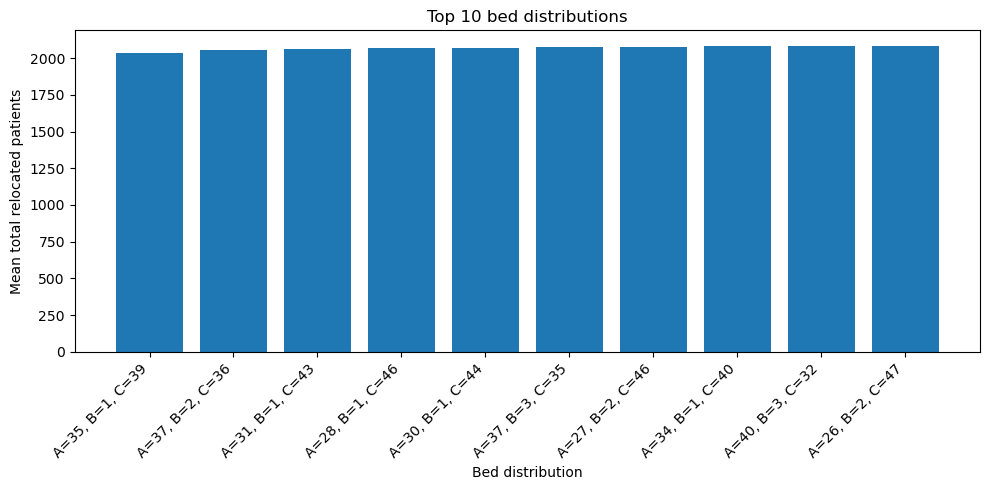

In [ ]:
np.random.seed(42)

print_summary(best_75)
plot_top_bed_distributions(top_75, n=10)

#### LOS sensitivity

In [25]:
best_A = best_75["beds_A"]
best_B = best_75["beds_B"]
best_C = best_75["beds_C"]

In [ ]:
np.random.seed(42)

lognormal_summary, lognormal_runs = simulate_repetitions(
    beds_A=best_A,
    beds_B=best_B,
    beds_C=best_C,
    total_beds=75,
    repetitions=50,
    LOS_exp=False
)

exponential_summary, exponential_runs = simulate_repetitions(
    beds_A=best_A,
    beds_B=best_B,
    beds_C=best_C,
    total_beds=75,
    repetitions=50,
    LOS_exp=True
)

In [ ]:
np.random.seed(42)

print("Lognormal LOS")
print_summary(lognormal_summary)

print()
print("=" * 50)
print()

print("Exponential LOS")
print_summary(exponential_summary)



Lognormal LOS
Total beds: 75
Bed distribution: A=35, B=1, C=39
LOS: Lognormal
Repetitions: 50

Mean total relocated: 2045.38
Std total relocated: 91.63

Mean relocated A: 1043.60
Mean relocated B: 198.22
Mean relocated C: 803.56

Mean full probability A: 0.4729
Mean full probability B: 0.9361
Mean full probability C: 0.3657

Mean relocation probability A: 0.4729
Mean relocation probability B: 0.4460
Mean relocation probability C: 0.3657

Mean utilization A: 0.8556
Mean utilization B: 0.8950
Mean utilization C: 0.9509

Mean overflow B to A: 217.66


Exponential LOS
Total beds: 75
Bed distribution: A=35, B=1, C=39
LOS: Exponential
Repetitions: 50

Mean total relocated: 2031.52
Std total relocated: 85.45

Mean relocated A: 1053.20
Mean relocated B: 199.46
Mean relocated C: 778.86

Mean full probability A: 0.4740
Mean full probability B: 0.9371
Mean full probability C: 0.3583

Mean relocation probability A: 0.4740
Mean relocation probability B: 0.4544
Mean relocation probability C: 0.3583


> ### Maybe not a very good plot, look at the bottom of the file for different plots you can also use

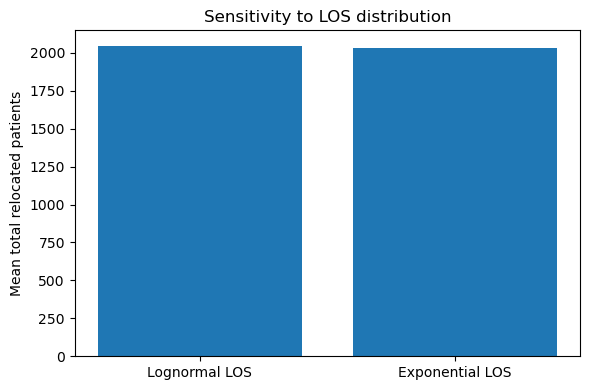

In [ ]:
np.random.seed(42)
plot_los_sensitivity(lognormal_summary, exponential_summary)

#### Bed sensitivity

In [ ]:
np.random.seed(42)
bed_total_results = total_beds_sensitivity(
    total_bed_values=[60, 70, 75, 80, 100],
    top_n=20,
    repetitions=20,
    LOS_exp=False
)


Testing total beds = 60
Total beds: 60
Bed distribution: A=39, B=1, C=20
LOS: Lognormal
Repetitions: 20

Mean total relocated: 2566.85
Std total relocated: 83.48

Mean relocated A: 941.95
Mean relocated B: 178.65
Mean relocated C: 1446.25

Mean full probability A: 0.4225
Mean full probability B: 0.9354
Mean full probability C: 0.6616

Mean relocation probability A: 0.4225
Mean relocation probability B: 0.4094
Mean relocation probability C: 0.6616

Mean utilization A: 0.8415
Mean utilization B: 0.8840
Mean utilization C: 0.9708

Mean overflow B to A: 228.95

Testing total beds = 70
Total beds: 70
Bed distribution: A=27, B=2, C=41
LOS: Lognormal
Repetitions: 20

Mean total relocated: 2227.90
Std total relocated: 62.23

Mean relocated A: 1277.15
Mean relocated B: 224.60
Mean relocated C: 726.15

Mean full probability A: 0.5784
Mean full probability B: 0.8715
Mean full probability C: 0.3311

Mean relocation probability A: 0.5784
Mean relocation probability B: 0.5171
Mean relocation probab

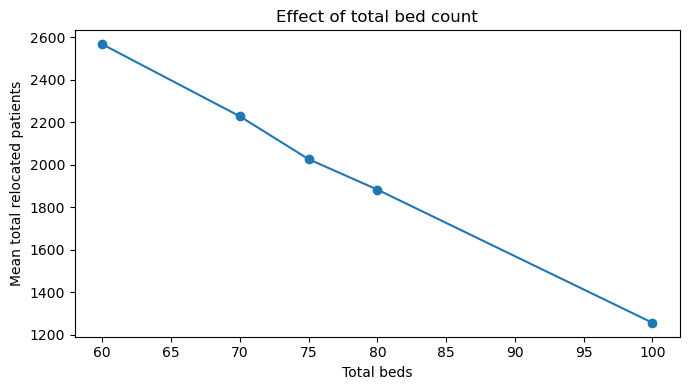

In [ ]:
np.random.seed(42)
plot_total_beds_sensitivity(bed_total_results)

# More suggested plots

### Primary performance measures, with improved bed dist

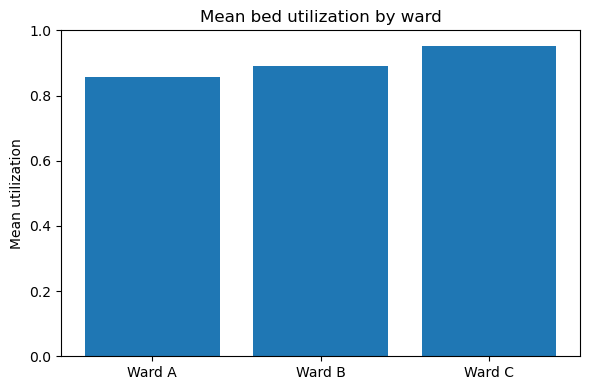

In [ ]:
np.random.seed(42)
plot_utilization_by_ward(best_75)

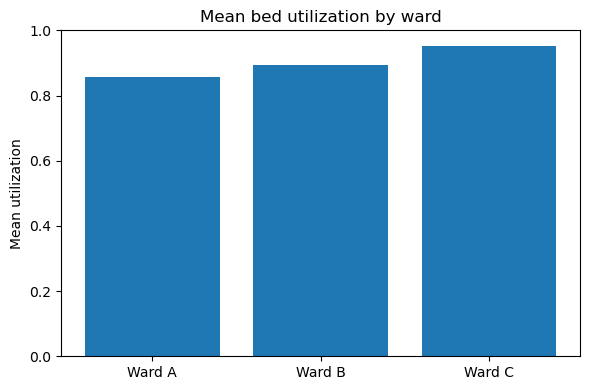

In [ ]:
np.random.seed(42)
plot_utilization_by_ward(lognormal_summary)

## LOS plots

### Distrubution comparison

In [33]:
def sample_los_lognormal(mu, sigma2, n=10000):
    sigma = np.sqrt(sigma2)
    return np.random.lognormal(mean=mu, sigma=sigma, size=n)

def sample_los_exponential(mu, sigma2, n=10000):
    # Same mean as the lognormal distribution
    mean_los = np.exp(mu + sigma2 / 2)
    return np.random.exponential(scale=mean_los, size=n)



def plot_los_distribution(mu, sigma2, ward_name, n=10000, max_days=60):
    lognormal_samples = sample_los_lognormal(mu, sigma2, n)
    exponential_samples = sample_los_exponential(mu, sigma2, n)

    plt.figure(figsize=(8, 5))

    plt.hist(
        lognormal_samples,
        bins=60,
        density=True,
        alpha=0.5,
        label="Lognormal LOS"
    )

    plt.hist(
        exponential_samples,
        bins=60,
        density=True,
        alpha=0.5,
        label="Exponential LOS"
    )

    plt.xlim(0, max_days)
    plt.xlabel("Length of stay in days")
    plt.ylabel("Density")
    plt.title(f"LOS distribution comparison, Ward {ward_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

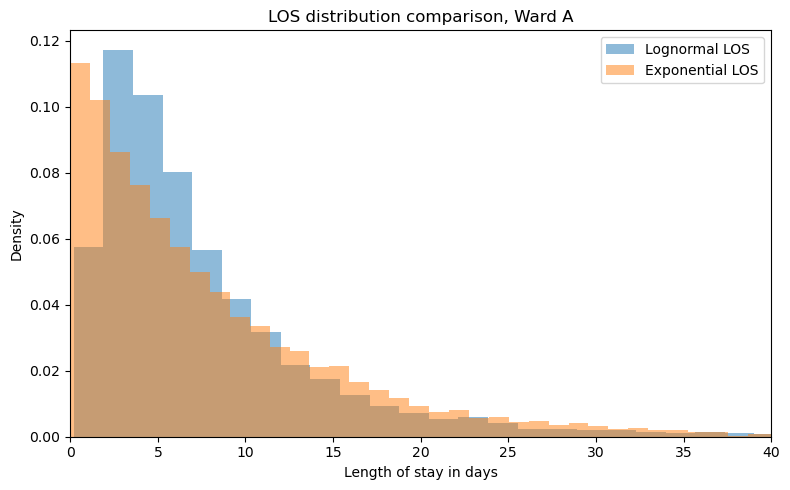

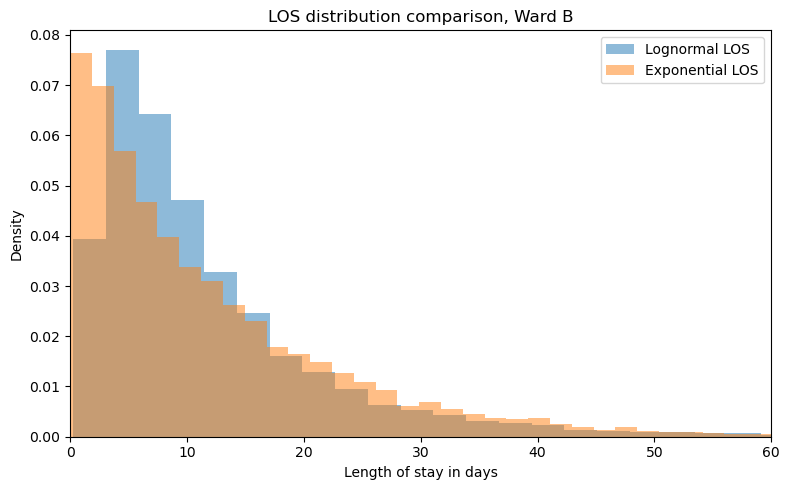

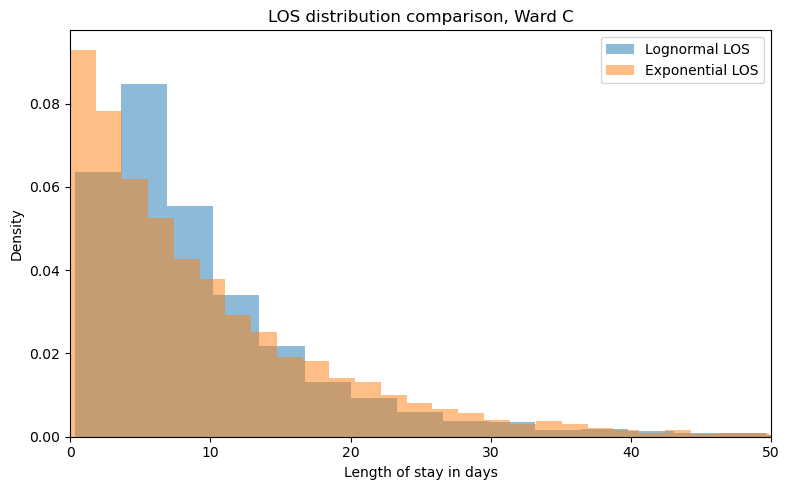

In [ ]:
np.random.seed(42)
plot_los_distribution(mu_A, sigma2, ward_name="A", max_days=40)
plot_los_distribution(mu_B, sigma2, ward_name="B", max_days=60)
plot_los_distribution(mu_C, sigma2, ward_name="C", max_days=50)

### plots of cdf

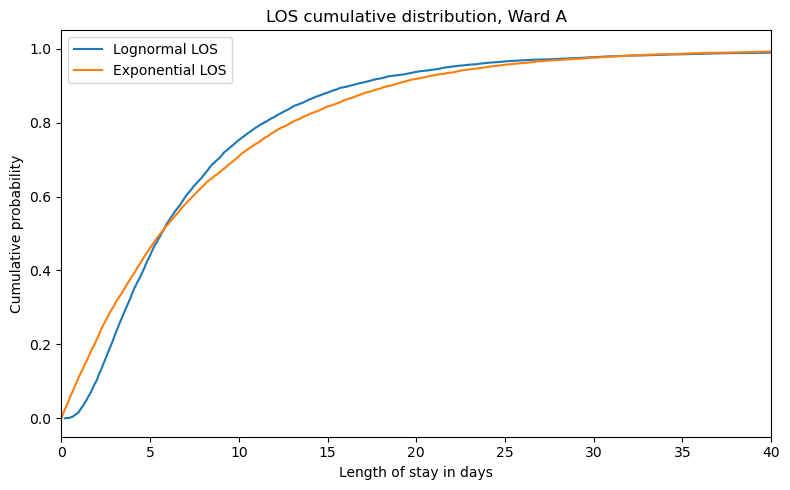

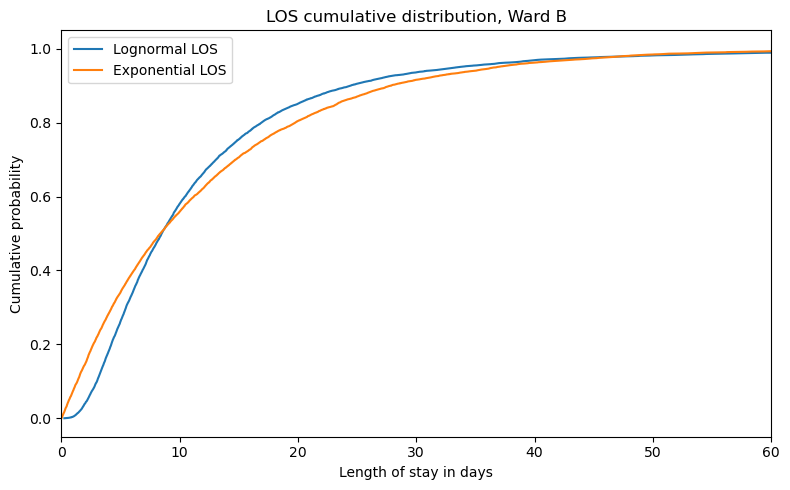

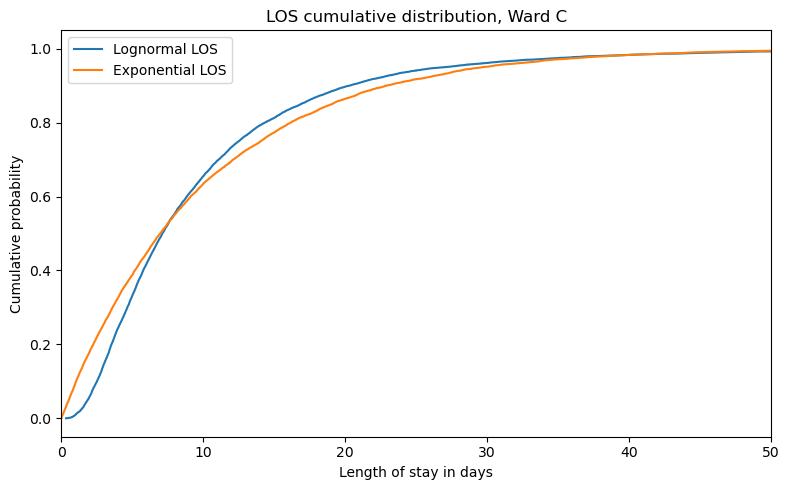

In [ ]:
def plot_los_cdf(mu, sigma2, ward_name, n=10000, max_days=60):
    lognormal_samples = sample_los_lognormal(mu, sigma2, n)
    exponential_samples = sample_los_exponential(mu, sigma2, n)

    lognormal_sorted = np.sort(lognormal_samples)
    exponential_sorted = np.sort(exponential_samples)

    y_values = np.arange(1, n + 1) / n

    plt.figure(figsize=(8, 5))

    plt.plot(lognormal_sorted, y_values, label="Lognormal LOS")
    plt.plot(exponential_sorted, y_values, label="Exponential LOS")

    plt.xlim(0, max_days)
    plt.xlabel("Length of stay in days")
    plt.ylabel("Cumulative probability")
    plt.title(f"LOS cumulative distribution, Ward {ward_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

np.random.seed(42)
plot_los_cdf(mu_A, sigma2, ward_name="A", max_days=40)
plot_los_cdf(mu_B, sigma2, ward_name="B", max_days=60)
plot_los_cdf(mu_C, sigma2, ward_name="C", max_days=50)

### Tail comparisons

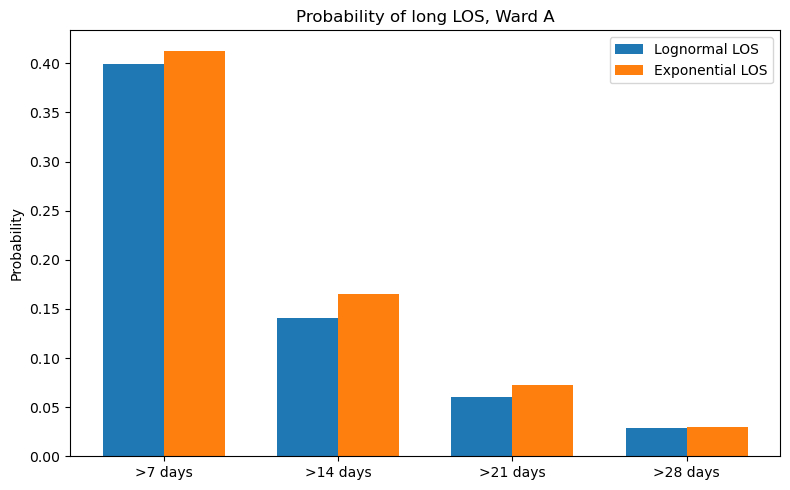

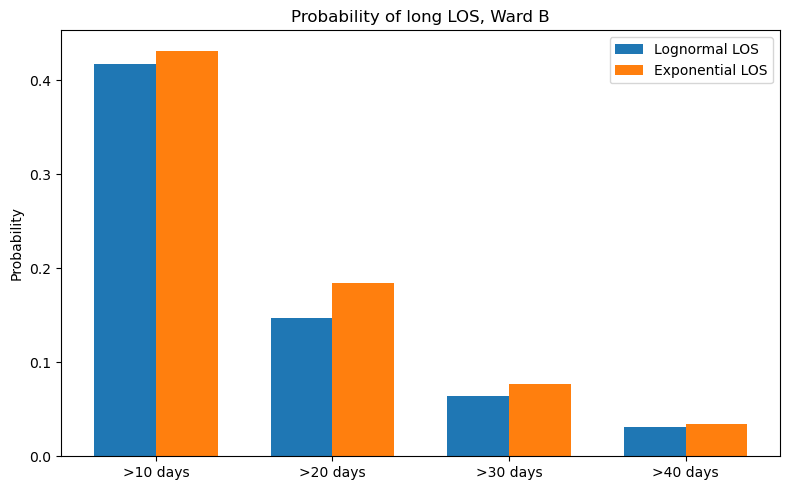

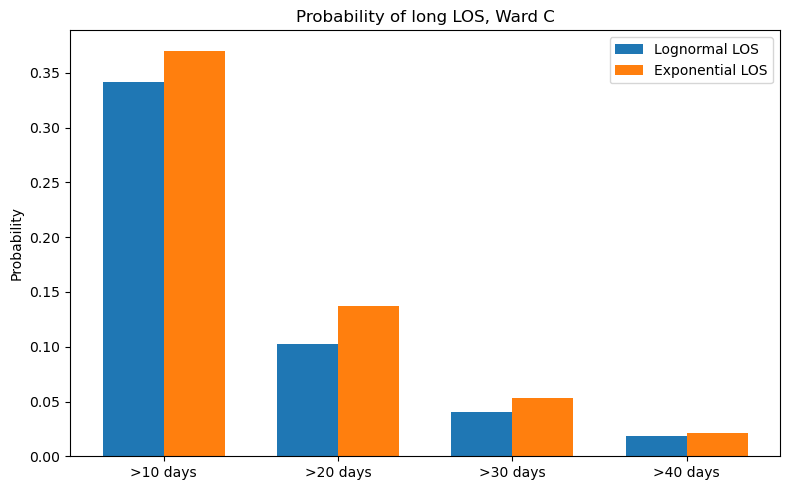

In [ ]:
def plot_los_tail_probabilities(mu, sigma2, ward_name, thresholds, n=10000):
    lognormal_samples = sample_los_lognormal(mu, sigma2, n)
    exponential_samples = sample_los_exponential(mu, sigma2, n)

    lognormal_tail_probs = []
    exponential_tail_probs = []

    for threshold in thresholds:
        lognormal_tail_probs.append(np.mean(lognormal_samples > threshold))
        exponential_tail_probs.append(np.mean(exponential_samples > threshold))

    x = np.arange(len(thresholds))
    width = 0.35

    plt.figure(figsize=(8, 5))

    plt.bar(
        x - width / 2,
        lognormal_tail_probs,
        width,
        label="Lognormal LOS"
    )

    plt.bar(
        x + width / 2,
        exponential_tail_probs,
        width,
        label="Exponential LOS"
    )

    plt.xticks(x, [f">{t} days" for t in thresholds])
    plt.ylabel("Probability")
    plt.title(f"Probability of long LOS, Ward {ward_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

np.random.seed(42)
plot_los_tail_probabilities(mu_A, sigma2, "A", thresholds=[7, 14, 21, 28])
plot_los_tail_probabilities(mu_B, sigma2, "B", thresholds=[10, 20, 30, 40])
plot_los_tail_probabilities(mu_C, sigma2, "C", thresholds=[10, 20, 30, 40])